# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [7]:
# James Watt 2026 UMD PHYS 265 LAB 1
import numpy as np
import scipy.constants as sc #just importing scipy constants in order to be able to get permittivity of free space
import matplotlib.pyplot as plt
#makes plots interactive! 
%matplotlib ipympl 

import math

from scipy.integrate import quad
from scipy.integrate import dblquad
from scipy.integrate import solve_ivp

#trying to get around using isInstance a million times I found Python has a typing library
from typing import Union

Number = Union[int, float]


G = 6.67e-11          #m^3/kg/s^2
g = 9.81               #earths gravity constant m/s^2
massEarth = 5.9e24     #kg
massMoon = 7.3e22      #kg
massApolloCM = 5500    #kg
radiusEarth = 6378000  #m
radiusMoon = 1737000   #m
avgEtoM = 3.8e8        #m
exVelSatV = 2.4e3      #m
burnRateSV = 1.3e4     #kg/s
wetMSV = 2.8e6         #kg
dryMSV = 7.5e5         #kg

def gravPotential(mass: Number, xM: Number, yM: Number, xE: Number, yE:Number,integration_window: float = 1e-3) -> float:
    """
    Compute the gravitational potential at point (xM, yM) due to a point mass M
    located at (xE, yE), using the integral definition of gravitational potential.

    The potential is computed from(should be 3-D coordinates but assume 2-D from problem specs):

        Φ(r) = -G ∫ (ρ(r') / |r - r'|) d^2r'

    where the mass density ρ(r') is modeled as:
    
        ρ(r') = M δ(x' - xm) δ(y' - ym)

    Integrating dirac deltas(0 everywhere except at one point infinity with finite integral=1) gives us wonky infinities or 0 where they should not be therefore as per the suggestion of my 313 TA
    I can try creating an "Integration Window" that would allow me to create a small square region around each mass location. This window
    is small enough to allow us to assume a uniform density patch and 

    ρ≈{ ( M/(2ϵ)^2) inside the patch,
    ρ≈{ (0)         outdside the patch

    basically replace the infinity in the dirac delta with a uniform density patch by approximating spreading the mass over a tiny finite area so our integration can work

    -----Inputs-----
    M : float or int
        Mass of the body (kg). Must be positive.
    xm, ym : float or int
        Cartesian coordinates of the mass (meters).
    x, y : float or int
        Cartesian coordinates of evaluation point (meters).
    integration_window : float, optional arguement if one wishes to change the area approximation
        Half-width of integration window around the mass location (meters).
        Default is 1e-3.

    -----Returns-----
    float
        Gravitational potential at (x, y) in Joules per kilogram (J/kg).

    Raises
    ------
    TypeError
        If inputs are not numeric.
    ValueError
        If mass is non-positive.
    ZeroDivisionError
        If evaluation point coincides with mass location.
    """
    #_____Type checks______
    for val in (mass, xM, yM, xE, yE, integration_window):
        if not isinstance(val, (int, float)):
            raise TypeError("All inputs must be numeric (int or float).")

    # ______Pre-conditions______

    if mass <= 0:
        raise ValueError("Mass M must be positive.")

    if integration_window <= 0:
        raise ValueError("Integration_window must be positive.")

    # Distance from evaluation point to mass
    r_eval = np.hypot(xM - xE, yM - yE)

    if r_eval == 0:
        raise ZeroDivisionError("Gravitational potential is singular at the mass location.")
    
    #______Integral Checker and Function_______
    def integralTime(yP: float, xP: float) -> float:
        """
        Integrand for Φ = -G ∫ ρ(r') / |r - r'| d^2r' or where the computation is done
        """
        r_prime_dist = np.hypot(xE - xP, yE - yP)
        if r_prime_dist == 0:
            return 0.0
        return 1.0 / r_prime_dist
        #notice density is constant therefore we will muliptly this result by it later

    #_____Setup Integration window with given points and compute calling integralTime, can you access function within a function without calling the parent?_____
    x_min = xM - integration_window
    x_max = xM + integration_window
    y_min = yM - integration_window
    y_max = yM + integration_window

    integral_value, _ = dblquad(integralTime, x_min, x_max, lambda _: y_min, lambda _: y_max)
    #NOTE Here we need a double integral or one for each coordinate given

    # Multiply by effective density mass / area; as mentioned in integralTime
    area = (2 * integration_window) ** 2
    rho_effective = mass / area

    potentialF = -G * rho_effective * integral_value

    #______Post-condition______
    if not np.isfinite(potentialF):
        raise ArithmeticError("Computed potential is not finite.")
        
    return float(potentialF)
    


    

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

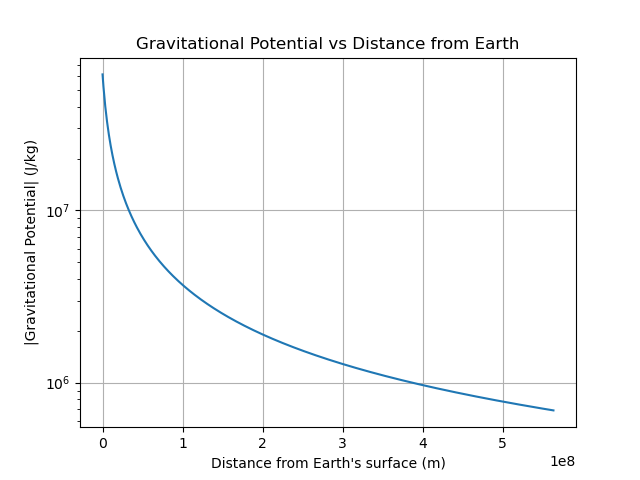

In [8]:
#______Distance range______
x_max = 1.5 * avgEtoM
x_values = np.linspace(radiusEarth, x_max, 500)

#_____Compute potential magnitude______
phi_values = []

for x in x_values:
    phi = gravPotential(mass=massEarth, xM=0.0, yM=0.0, xE=x, yE=0.0)
    phi_values.append(abs(phi))

phi_values = np.array(phi_values)

#______Plot______
plt.figure()
plt.plot(x_values - radiusEarth, phi_values)
plt.yscale("log")
plt.xlabel("Distance from Earth's surface (m)")
plt.ylabel("|Gravitational Potential| (J/kg)")
plt.title("Gravitational Potential vs Distance from Earth")
plt.grid(True)
plt.show()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

In [ ]:
moonX = avgEtoM/sqrt(2)
moonY = avgEtoM/sqrt(2)



2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

And your updated plot, including the balance point, goes in the cell below.

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**